In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [12]:
import pandas as pd

columns = (
    ["engine_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

test = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

rul = pd.read_csv(
    "data/RUL_FD001.txt",
    header=None,
    names=["RUL"],              # RUL = Remaining Useful Life
)

Failure Cycle of Every Engine

In [13]:
max_cycles = train.groupby("engine_id")["cycle"].max().reset_index()

max_cycles.columns = [
    "engine_id",
    "max_cycle"
]

max_cycles.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [14]:
train = train.merge(
    max_cycles,
    on="engine_id",
    how="left"
)

In [17]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [16]:
train["RUL"] = (
    train["max_cycle"]
    - train["cycle"]
)

In [22]:
train.groupby("engine_id").tail(1).head(10)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,21.61,551.25,2388.32,9033.22,1.3,48.25,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0
478,2,287,-0.0005,0.0006,100.0,518.67,643.85,1608.50,1430.84,14.62,21.61,551.66,2388.20,9109.36,1.3,48.12,519.81,2388.21,8175.57,8.5365,0.03,398,2388,100.0,38.43,23.0848,0
657,3,179,0.0012,0.0000,100.0,518.67,643.51,1604.80,1428.23,14.62,21.61,551.91,2388.14,9197.52,1.3,48.09,519.53,2388.20,8255.34,8.5056,0.03,398,2388,100.0,38.40,22.9562,0
846,4,189,-0.0024,-0.0002,100.0,518.67,644.53,1612.11,1432.55,14.62,21.61,551.93,2388.13,9198.32,1.3,48.15,519.84,2388.16,8259.42,8.5246,0.03,398,2388,100.0,38.44,23.1006,0
1115,5,269,0.0022,0.0003,100.0,518.67,643.46,1597.28,1430.74,14.62,21.61,550.77,2388.18,9157.05,1.3,48.26,519.86,2388.16,8212.75,8.5209,0.03,397,2388,100.0,38.45,23.0296,0
1303,6,188,0.0014,-0.0004,100.0,518.67,643.47,1600.63,1434.92,14.62,21.61,550.70,2388.34,9027.96,1.3,48.21,518.98,2388.34,8102.82,8.5358,0.03,397,2388,100.0,38.42,22.9577,0
1562,7,259,0.0043,-0.0001,100.0,518.67,644.15,1599.33,1435.04,14.62,21.61,551.97,2388.19,9075.94,1.3,47.97,519.10,2388.24,8145.75,8.5162,0.03,396,2388,100.0,38.46,23.0596,0
1712,8,150,0.0026,-0.0003,100.0,518.67,643.87,1602.84,1432.31,14.62,21.61,551.08,2388.27,9046.16,1.3,48.24,519.57,2388.26,8121.27,8.5509,0.03,394,2388,100.0,38.24,23.0510,0
1913,9,201,-0.0016,0.0004,100.0,518.67,644.04,1595.36,1428.43,14.62,21.61,552.30,2388.50,9239.76,1.3,48.11,520.28,2388.56,8289.63,8.5156,0.03,399,2388,100.0,38.45,23.0284,0
2135,10,222,0.0002,-0.0003,100.0,518.67,643.66,1599.18,1436.29,14.62,21.61,552.70,2388.22,9115.44,1.3,48.09,520.02,2388.16,8183.55,8.5159,0.03,398,2388,100.0,38.51,23.1434,0


In [ ]:
train.drop(
    columns="max_cycle",
    inplace=True
) 


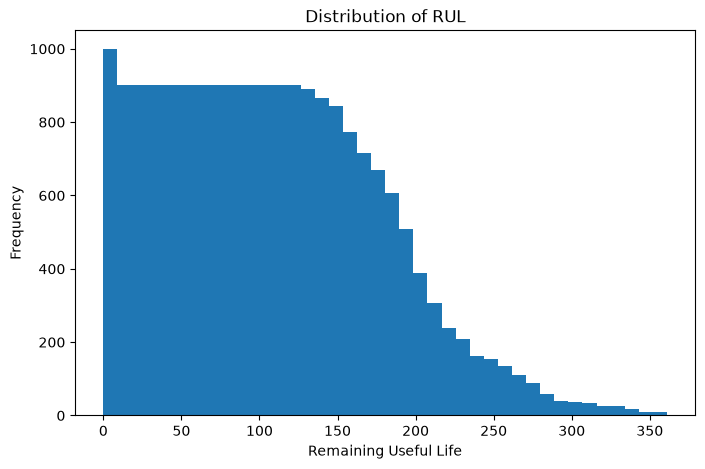

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train["RUL"], bins=40)

plt.xlabel("Remaining Useful Life")

plt.ylabel("Frequency")

plt.title("Distribution of RUL")

plt.show()

### Preparing test data

In [24]:
test_last_cycle = (
    test.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

test_last_cycle.columns = [
    "engine_id",
    "last_cycle"
]

test_last_cycle.head()

,engine_id,last_cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [26]:
rul["engine_id"] = range(
    1,
    len(rul) + 1
)

test_last_cycle = test_last_cycle.merge(
    rul,
    on="engine_id",
    how="left"
)

test_last_cycle.head()

,engine_id,last_cycle,RUL
0,1,31,112
1,2,49,98
2,3,126,69
3,4,106,82
4,5,98,91


In [27]:
test = test.merge(
    test_last_cycle,
    on="engine_id",
    how="left"
)

test["RUL"] = (
    test["last_cycle"]
    - test["cycle"]
    + test["RUL"]
)

In [31]:
test[
    ["engine_id", "cycle", "RUL"]
].head(10)

,engine_id,cycle,RUL
0,1,1,142
1,1,2,141
2,1,3,140
3,1,4,139
4,1,5,138
5,1,6,137
6,1,7,136
7,1,8,135
8,1,9,134
9,1,10,133


In [29]:
test.drop(
    columns="last_cycle",
    inplace=True
)

In [32]:
test_final = (
    test.groupby("engine_id")
    .tail(1)
    .reset_index(drop=True)
)

In [33]:
test_final[
    ["engine_id", "cycle", "RUL"]
].head(10)

,engine_id,cycle,RUL
0,1,31,112
1,2,49,98
2,3,126,69
3,4,106,82
4,5,98,91
5,6,105,93
6,7,160,91
7,8,166,95
8,9,55,111
9,10,192,96


Remove Constant & Low-Information Sensors

In [40]:
sensor_columns = [
    "sensor_2", "sensor_3", "sensor_4",
    "sensor_6", "sensor_7", "sensor_8",
    "sensor_9", "sensor_11", "sensor_12",
    "sensor_13", "sensor_14", "sensor_15",
    "sensor_17", "sensor_20", "sensor_21"
]

In [36]:
train[sensor_columns].nunique()

sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
dtype: int64

In [37]:
constant_sensors = [
    col
    for col in sensor_columns
    if train[col].nunique() <= 1
]

constant_sensors

['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

In [38]:
train.drop(
    columns=constant_sensors,
    inplace=True
)

test.drop(
    columns=constant_sensors,
    inplace=True
)

In [41]:
variance = train[sensor_columns].var()

variance.sort_values()

sensor_6       0.000002
sensor_15      0.001407
sensor_8       0.005039
sensor_13      0.005172
sensor_21      0.011718
sensor_20      0.032669
sensor_11      0.071336
sensor_2       0.250053
sensor_12      0.543985
sensor_7       0.783388
sensor_17      2.398667
sensor_3      37.590994
sensor_4      81.010886
sensor_14    363.900490
sensor_9     487.653568
dtype: float64

In [42]:
low_variance_sensors = variance[
    variance < 0.01
].index.tolist()

low_variance_sensors

['sensor_6', 'sensor_8', 'sensor_13', 'sensor_15']

In [55]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [54]:
train.drop(columns=['sensor_6'], inplace=True)

In [56]:
test.drop(columns=['sensor_6'], inplace=True)

In [57]:
sensor_columns = [
    col for col in sensor_columns
    if col not in constant_sensors
]

In [58]:
len(sensor_columns)

15

In [60]:
train_features = [
    col for col in train.columns
    if col.startswith("sensor_")
]

test_features = [
    col for col in test.columns
    if col.startswith("sensor_")
]

print("Training sensors:", len(train_features))
print("Test sensors:", len(test_features))

print(
    "Same features:",
    train_features == test_features
)

Training sensors: 14
Test sensors: 14
Same features: True


In [61]:
train.to_csv("train_features.csv", index=False)
test.to_csv("test_features.csv", index=False)

In [2]:
train = pd.read_csv("train_features.csv")
test = pd.read_csv("test_features.csv")

### Sensor–RUL Relationship

In [3]:
sensor_cols = [col for col in train.columns if col.startswith("sensor_")]

In [4]:
sensor_rul_corr = train[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')

sensor_rul_corr

sensor_2    -0.606484
sensor_3    -0.584520
sensor_4    -0.678948
sensor_7     0.657223
sensor_8    -0.563968
sensor_9    -0.390102
sensor_11   -0.696228
sensor_12    0.671983
sensor_13   -0.562569
sensor_14   -0.306769
sensor_15   -0.642667
sensor_17   -0.606154
sensor_20    0.629428
sensor_21    0.635662
Name: RUL, dtype: float64

In [5]:
sensor_rul_corr_sorted = (
    sensor_rul_corr
    .abs()
    .sort_values(ascending=False)
)

sensor_rul_corr_sorted

sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
sensor_14    0.306769
Name: RUL, dtype: float64

In [6]:
sensor_rul_corr_df = pd.DataFrame({
    'Correlation': sensor_rul_corr,
    'Absolute_Correlation': sensor_rul_corr.abs()
}).sort_values(
    'Absolute_Correlation',
    ascending=False
)

sensor_rul_corr_df

,Correlation,Absolute_Correlation
sensor_11,-0.696228,0.696228
sensor_4,-0.678948,0.678948
sensor_12,0.671983,0.671983
sensor_7,0.657223,0.657223
sensor_15,-0.642667,0.642667
sensor_21,0.635662,0.635662
sensor_20,0.629428,0.629428
sensor_2,-0.606484,0.606484
sensor_17,-0.606154,0.606154
sensor_3,-0.584520,0.584520


In [7]:
strongest_sensor = sensor_rul_corr_df.index[0]

strongest_sensor

'sensor_11'

In [8]:
sensor_rul_corr_df.sort_values(
    'Absolute_Correlation'
).head(10)

,Correlation,Absolute_Correlation
sensor_14,-0.306769,0.306769
sensor_9,-0.390102,0.390102
sensor_13,-0.562569,0.562569
sensor_8,-0.563968,0.563968
sensor_3,-0.584520,0.584520
sensor_17,-0.606154,0.606154
sensor_2,-0.606484,0.606484
sensor_20,0.629428,0.629428
sensor_21,0.635662,0.635662
sensor_15,-0.642667,0.642667


In [9]:
sensor_corr = train[sensor_cols].corr()

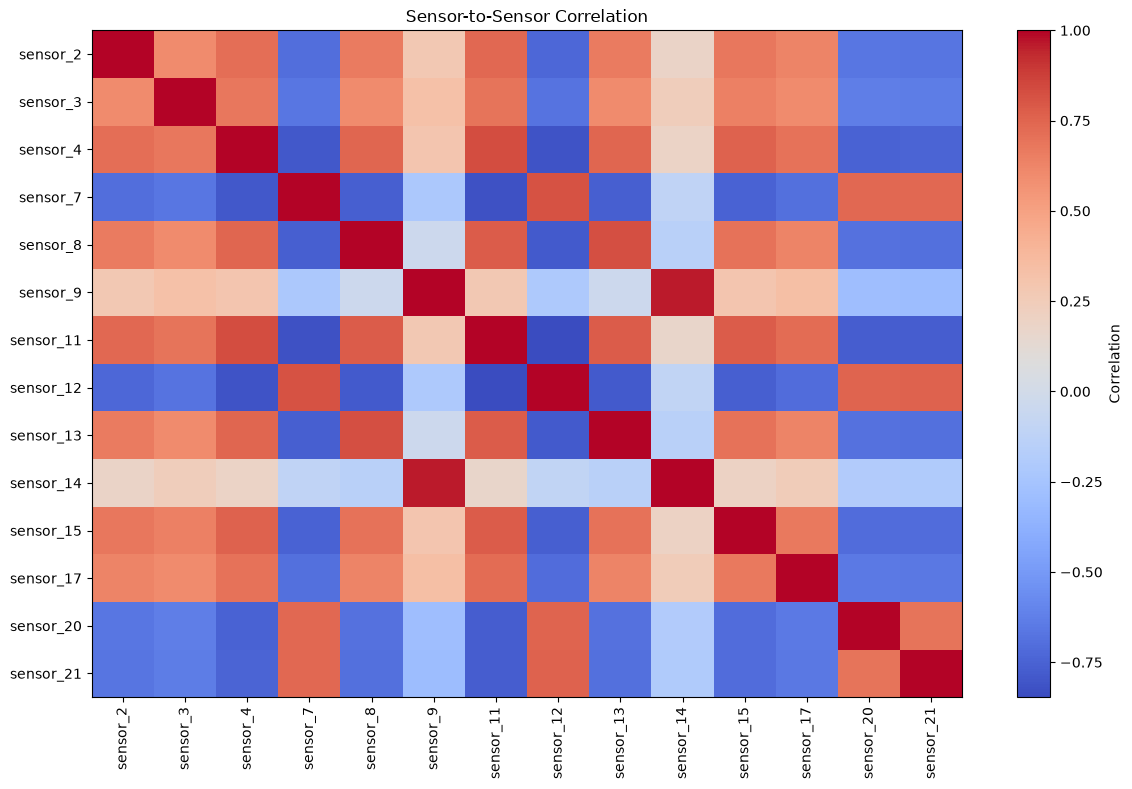

In [74]:
plt.figure(figsize=(12, 8))

plt.imshow(sensor_corr, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(sensor_cols)),
    sensor_cols,
    rotation=90
)

plt.yticks(
    range(len(sensor_cols)),
    sensor_cols
)

plt.title("Sensor-to-Sensor Correlation")

plt.tight_layout()
plt.show()

### Feature Scaling

In [10]:
X = train.drop(columns=['RUL'])
y = train['RUL']

In [11]:
X.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21'],
      dtype='object')

In [12]:
sensor_cols = [
    col for col in train.columns
    if col.startswith('sensor_')
]

In [13]:
feature_cols = [
    col for col in train.columns
    if col.startswith('op_setting_')
] + sensor_cols

In [14]:
feature_cols = (
    ['cycle'] +
    [col for col in train.columns if col.startswith('op_setting_')] +
    sensor_cols
)

In [17]:
train.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

X = train[feature_cols]
y = train['RUL']
groups = train['engine_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [19]:
X_train.shape, X_val.shape

((16561, 18), (4070, 18))

Verifying that engines don't overlap

In [21]:
train_units = set(train.iloc[train_idx]['engine_id'])
val_units = set(train.iloc[val_idx]['engine_id'])

len(train_units), len(val_units)

(80, 20)

In [ ]:
train_units.intersection(val_units)   # set() means no engine appears in both training and validation

set()

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [26]:
scaler.fit(X_train)

StandardScaler()

In [27]:
X_train_scaled = scaler.transform(X_train)

X_val_scaled = scaler.transform(X_val)

In [28]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=feature_cols,
    index=X_val.index
)

In [33]:
X_train_scaled.to_csv("train_scaled.csv", index=False)
X_val_scaled.to_csv("val_scaled.csv", index=False)

In [36]:
y_train.to_csv("y_train_scaled.csv", index=False)
y_val.to_csv("y_val_scaled.csv", index=False)

In [34]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']